In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

In [2]:
from matplotlib.lines import Line2D

In [3]:
from matplotlib.patches import Patch

In [16]:
molecules = ['heh+','h2']
bases = ['sto-3g','3-21g','6-31g','6-31gss']

gaplookup = {}
freqlookup = {}

mygaps = [(0,1),(0,2),(1,2),(0,3),(1,3),(2,3)]
allgapstr = []
for gap in mygaps:
    gapstr = "E"+str(gap[1])+"-E"+str(gap[0])+""
    allgapstr.append(gapstr)

allowedgaps = {}
alldata = {}

for mol in molecules:
    for basis in bases:
        fname = './psi4data/cis_' + mol + '_' + basis + '.npz'
        datfile = np.load(fname)
        h0 = datfile['ham']
        allowedgaps[(mol,basis)] = []
        for gap in mygaps:
            if gap[1]>=h0.shape[0]:
                continue
            if gap[0]>=h0.shape[0]:
                continue
            freq = np.round((h0[gap[1]]-h0[gap[0]])/(2*np.pi),6)
            freqstr = str(freq)
            while len(freqstr) < 8:
                freqstr += "0"
            gapstr = "E"+str(gap[1])+"-E"+str(gap[0])+""
            allowedgaps[(mol,basis)].append(gapstr)
            gaplookup[(mol,basis,freqstr)] = gapstr
            freqlookup[(mol,basis,gapstr)] = freqstr
            fname = "./new_cis_fieldon_results/cis_"+mol+"_"+basis+"_0.010000_"+freqstr+"_0.100000_5.txt"
            alldata[(mol,basis,gapstr)] = np.loadtxt(fname, skiprows=3, delimiter=',')

In [22]:
# illustrating these lookup table tools
print(freqlookup['heh+','3-21g','E1-E0'])

0.124949


In [23]:
# for each basis set, rank the gaps
argsorts = {}
for mol in molecules:
    for basis in bases:
        freqs = []
        for gap in range(6):
            if (mol,basis,allgapstr[gap]) in freqlookup:
                freqs.append(freqlookup[(mol,basis,allgapstr[gap])])
        # sortedfreq, sortedgapstr = zip(*sorted(zip(sixfreq, allgapstr)))
        argsorts[(mol, basis)] = np.argsort(np.array(list(map(float,freqs))))

In [31]:
mol = 'h2'
basis = 'sto-3g'
for j in argsorts[mol,basis]:
    print( allowedgaps[mol,basis][j] )
    print( freqlookup[mol,basis,allowedgaps[mol,basis][j]] )

print("")

mol = 'h2'
basis = '6-31gss'
for j in argsorts[mol,basis]:
    print( allowedgaps[mol,basis][j] )
    print( freqlookup[mol,basis,allowedgaps[mol,basis][j]] )

E2-E1
0.057681
E1-E0
0.093263
E2-E0
0.150944

E2-E1
0.027892
E3-E2
0.042590
E1-E0
0.060476
E3-E1
0.070481
E2-E0
0.088367
E3-E0
0.130957


[0.14285714 0.28571429 0.42857143 0.57142857 0.71428571 0.85714286]


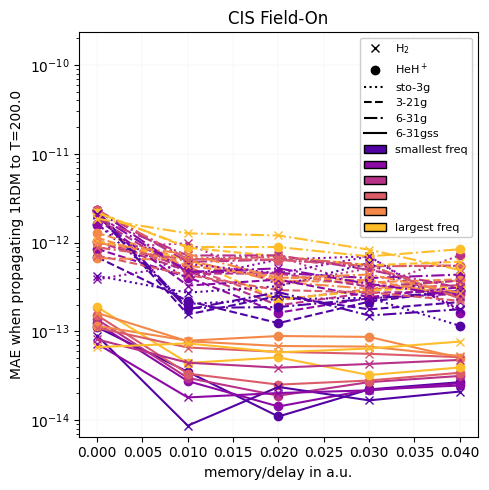

In [47]:
# try plasma colormap
# see https://matplotlib.org/stable/gallery/color/colormap_reference.html
# after this, cmap(0.5) will be the middle color in the color map
# also see https://matplotlib.org/stable/gallery/color/named_colors.html
cmap = matplotlib.colormaps['plasma']
cvals = np.linspace(0,1,8)[1:-1]
print(cvals)

plt.figure(figsize=(5,5))

mysize = 4.5

dt = 0.01

valsU = []
valsL = []

for mol in molecules:
    if mol=='h2':
        mrk = 'x'
    else:
        mrk = 'o'
    for basis in bases:
        if basis=='sto-3g':
            ls = ':'
        elif basis=='3-21g':
            ls = '--'
        elif basis=='6-31g':
            ls = '-.'
        else:
            ls = '-'
        k = 0
        for j in argsorts[mol,basis]:
            gapstr = allowedgaps[mol, basis][j]
            yvals = alldata[mol, basis, gapstr][:,1]
            valsU.append(np.max(yvals))
            valsL.append(np.min(yvals))
            plt.semilogy( dt*np.arange(5), yvals, marker=mrk, linestyle=ls, color=cmap(cvals[k]) )
            k += 1
    

custom_handles = [
    # Molecules
    Line2D([0], [0], color='black', marker='x', linestyle='None', label=f"H$_2$"),
    Line2D([0], [0], color='black', marker='o', linestyle='None', label=f"HeH$^+$"),
    
    # Basis Sets
    Line2D([0], [0], color='black', linestyle=':', label='sto-3g'),
    Line2D([0], [0], color='black', linestyle='--', label='3-21g'),
    Line2D([0], [0], color='black', linestyle='-.', label='6-31g'),
    Line2D([0], [0], color='black', linestyle='-', label='6-31gss'),
    
    # "Colorbar" Patches
    Patch(facecolor=cmap(cvals[0]), edgecolor='black', label='smallest freq'),
    Patch(facecolor=cmap(cvals[1]), edgecolor='black', label=''),
    Patch(facecolor=cmap(cvals[2]), edgecolor='black', label=''),
    Patch(facecolor=cmap(cvals[3]), edgecolor='black', label=''),
    Patch(facecolor=cmap(cvals[4]), edgecolor='black', label=''),
    Patch(facecolor=cmap(cvals[5]), edgecolor='black', label='largest freq')
]

# Pass the updated handles to your legend
plt.legend(handles=custom_handles, loc="upper right", fontsize=8)


plt.xlabel('memory/delay in a.u.')
plt.ylabel('MAE when propagating 1RDM to T=200.0')
plt.ylim([np.min(valsL)*0.75, np.max(valsU)*100.1])

# Pass the custom handles directly to the legend
plt.grid(True, color='lightgrey', linewidth=0.1)
plt.legend(framealpha=1.0, facecolor='white',handles=custom_handles, loc="upper right", fontsize=8) 
plt.title(r'CIS Field-On')
plt.tight_layout()
plt.savefig('CIS_FO.pdf')
plt.show()


In [39]:
print(np.max(vals))

2.3368141234884647e-12
